# **House Pricing modelling**

**Author:** Ambrose Chan Pak Yeung

**Data source:** Kaggle *Housing Prices Competition for Kaggle Learn Users* (`https://www.kaggle.com/competitions/home-data-for-ml-course/data`)

This notebook builds a simple machine learning model, with some eda and model validation.

## **1. Import libraries and load data**

In [1]:
# Section 1: Importing necessary libraries
import pandas as pd

# Section 2: Importing encoder 
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

# Correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

# Section 3: Importing machine learning libraries
from sklearn.tree import DecisionTreeRegressor

# Section 4: Importing additional libraries for model evaluation and splitting the dataset
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

# Section 6: Importing Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

# Section 7: Importing XGBoost Regressor
from xgboost import XGBRegressor

In [2]:
# Load and read dataset
house_data = pd.read_csv('house_train.csv')

# Display the first few rows of the dataset
house_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## **2. EDA**

In [3]:
# Display summary statistics of the dataset
house_data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [4]:
# Identifying the data types
house_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [5]:
# Get list of categorical variables
cat_list = house_data.select_dtypes(include=['str'])
print (cat_list.columns)
print (len(cat_list.columns))

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='str')
43


In [6]:
# Missing values in the dataset
missing = cat_list.isna().sum()
missing_pct = (missing / len(house_data) * 100).round(1)
pd.DataFrame({'missing': missing, 'pct': missing_pct}).sort_values('pct', ascending=False).head(5)

,missing,pct
PoolQC,1453,99.5
MiscFeature,1406,96.3
Alley,1369,93.8
Fence,1179,80.8
MasVnrType,872,59.7


In [7]:
# Checking for low cardinality categorical variables
low_cardinality_cols = [cname for cname in house_data.columns if house_data[cname].nunique() < 3 and 
                        house_data[cname].dtype == "str"]
print(low_cardinality_cols)

['Street', 'Alley', 'Utilities', 'CentralAir']


In [8]:
# Checking for high dominance categorical variables
object_cols_all = house_data.select_dtypes(include='object').columns

dominance = {}
for col in object_cols_all:
    top_share = house_data[col].value_counts(normalize=True).iloc[0]
    dominance[col] = top_share

dominance_series = pd.Series(dominance).sort_values(ascending=False)
dominance_series.head(5)

/var/folders/jn/b636r6qs7f31zbqc_6rntfrw0000gn/T/ipykernel_22640/1215187580.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols_all = house_data.select_dtypes(include='object').columns


Utilities     0.999315
Street        0.995890
Condition2    0.989726
RoofMatl      0.982192
Heating       0.978082
dtype: float64

To tackle with categorical columns, three different approaches are used. 

1. We will remove features with most missing values and columns that are redundant to other features
2. Ordinal encoding would be used for  `ExterQual`, `ExterCond`, `HeatingQC`, `KitchenQual`, `BsmtQual`, `BsmtCond`, `FireplaceQu`, `GarageQual`, `GarageCond`, all with same quality scale. Ordinal encoding would also be used on some other features.
3. We use `OneHotEncoder` for other nominal features.

Based on the observations above, we will remove categorical values with high missing values, low cardinality and high dominance.

In [9]:
# Removing categorical variables from the dataset
house_data_dropped = house_data.drop(columns=['Alley', 'PoolQC', 'Fence', 'MiscFeature', 'CentralAir',
                                              'Street', 'Utilities', 'Condition2', 'RoofMatl', 'Heating']).copy()

In [10]:
# Converting categorical variables to numerical using ordinal encoding
# Quality scales requires manual mapping (to avoid alphabetical ordering)

qual_cols = ['ExterQual', 'ExterCond', 'HeatingQC', 'KitchenQual', 'BsmtQual', 'BsmtCond', 'FireplaceQu', 'GarageQual', 'GarageCond']

house_data_dropped[qual_cols] = house_data_dropped[qual_cols].fillna('None')
qual_order = ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
ordinal_encoder_qual = OrdinalEncoder(categories=[qual_order] * len(qual_cols))
house_data_dropped[qual_cols] = ordinal_encoder_qual.fit_transform(house_data_dropped[qual_cols])

house_data_dropped['BsmtExposure'] = house_data_dropped['BsmtExposure'].fillna('None')
expo_order = ['None', 'No', 'Mn', 'Av', 'Gd']
ordinal_encoder_expo = OrdinalEncoder(categories=[expo_order])
house_data_dropped['BsmtExposure'] = ordinal_encoder_expo.fit_transform(house_data_dropped[['BsmtExposure']])

Fintype_cols = ['BsmtFinType1', 'BsmtFinType2']

house_data_dropped[Fintype_cols] = house_data_dropped[Fintype_cols].fillna('None')
fintype_order = ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']
ordinal_encoder_fintype = OrdinalEncoder(categories=[fintype_order] * len(Fintype_cols))
house_data_dropped[Fintype_cols] = ordinal_encoder_fintype.fit_transform(house_data_dropped[Fintype_cols])

garage_order = ['None', 'Unf', 'RFn', 'Fin']
house_data_dropped['GarageFinish'] = house_data_dropped['GarageFinish'].fillna('None')
ordinal_encoder_garage = OrdinalEncoder(categories=[garage_order])
house_data_dropped['GarageFinish'] = ordinal_encoder_garage.fit_transform(house_data_dropped[['GarageFinish']])

functional_order = ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ']
ordinal_encoder_functional = OrdinalEncoder(categories=[functional_order])
house_data_dropped['Functional'] = ordinal_encoder_functional.fit_transform(house_data_dropped[['Functional']])

lotshape_order = ['IR3', 'IR2', 'IR1', 'Reg']
ordinal_encoder_lotshape = OrdinalEncoder(categories=[lotshape_order])
house_data_dropped['LotShape'] = ordinal_encoder_lotshape.fit_transform(house_data_dropped[['LotShape']])

landslope_order = ['Sev', 'Mod', 'Gtl']
ordinal_encoder_landslope = OrdinalEncoder(categories=[landslope_order])
house_data_dropped['LandSlope'] = ordinal_encoder_landslope.fit_transform(house_data_dropped[['LandSlope']])

ordinal_encoder_paved = OrdinalEncoder()
house_data_dropped['PavedDrive'] = ordinal_encoder_paved.fit_transform(house_data_dropped[['PavedDrive']])

In [11]:
# Remaining categorical variables in the dataset
object_cols = house_data_dropped.select_dtypes(include='str').columns.tolist()
print(object_cols)

house_data_dropped[object_cols] = house_data_dropped[object_cols].fillna('None')

['MSZoning', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 'BldgType', 'HouseStyle', 'RoofStyle', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Electrical', 'GarageType', 'SaleType', 'SaleCondition']


In [12]:
# Converting categorical variables to numerical using OneHot Encoding
OH_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
OH_cols = pd.DataFrame(
    OH_encoder.fit_transform(house_data_dropped[object_cols]),
    columns=OH_encoder.get_feature_names_out(object_cols)
)

# One-hot encoding removed index; put it back
OH_cols.index = house_data_dropped.index

# Remove categorical columns (will replace with one-hot encoding)
num_house_data = house_data_dropped.drop(object_cols, axis=1)

# Add one-hot encoded columns to numerical features
house_data_clean = pd.concat([num_house_data, OH_cols], axis=1)

# Ensure all columns have string type
house_data_clean.columns = house_data_clean.columns.astype(str)

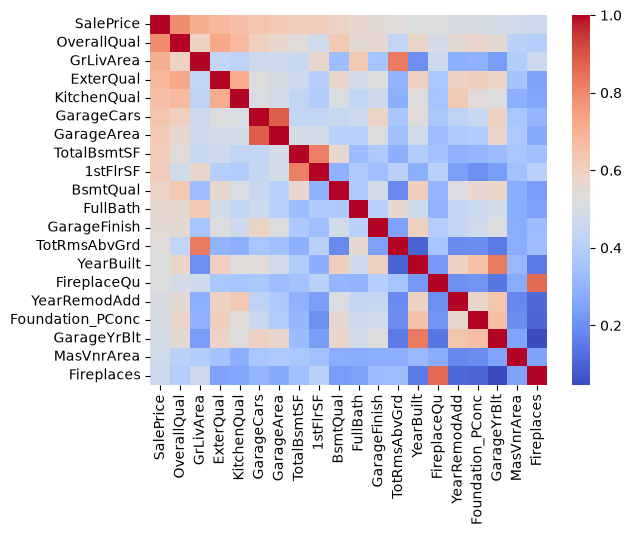

SalePrice           1.000000
OverallQual         0.790982
GrLivArea           0.708624
ExterQual           0.682639
KitchenQual         0.659600
GarageCars          0.640409
GarageArea          0.623431
TotalBsmtSF         0.613581
1stFlrSF            0.605852
BsmtQual            0.585207
FullBath            0.560664
GarageFinish        0.549247
TotRmsAbvGrd        0.533723
YearBuilt           0.522897
FireplaceQu         0.520438
YearRemodAdd        0.507101
Foundation_PConc    0.497734
GarageYrBlt         0.486362
MasVnrArea          0.477493
Fireplaces          0.466929
Name: SalePrice, dtype: float64
Index(['SalePrice', 'OverallQual', 'GrLivArea', 'ExterQual', 'KitchenQual',
       'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'BsmtQual',
       'FullBath', 'GarageFinish', 'TotRmsAbvGrd', 'YearBuilt', 'FireplaceQu',
       'YearRemodAdd', 'Foundation_PConc', 'GarageYrBlt', 'MasVnrArea',
       'Fireplaces'],
      dtype='str')


In [13]:
# Correlation of features with SalePrice
corr = house_data_clean.corr()['SalePrice'].sort_values(ascending=False)

top_cols = corr.head(20).index
sns.heatmap(house_data_clean[top_cols].corr(), annot=False, cmap='coolwarm')
plt.show()

print(corr.head(20))
print(top_cols)



Based on the correlation heatmap against `SalePrice`, the strongest numeric/ordinal predictors were OverallQual, GrLivArea, ExterQual, KitchenQual, GarageCars, TotalBsmtSF, BsmtQual, FullBath, GarageFinish, YearBuilt, and FireplaceQu. 

GarageArea, 1stFlrSF, and TotRmsAbvGrd were excluded despite similar correlation strength, since they were highly correlated with GarageCars, TotalBsmtSF, and GrLivArea respectively. To reduce redundancy, these features were removed. 

`Neighborhood` was added separately (one-hot encoded) based on real-life market observation, since location influences the housing price mainly.

In [14]:
# Verifying the instinct that similar features are redundant
house_data_dropped[['GarageCars','GarageArea','TotalBsmtSF','1stFlrSF','TotRmsAbvGrd','GrLivArea']].corr()

,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,TotRmsAbvGrd,GrLivArea
GarageCars,1.000000,0.882475,0.434585,0.439317,0.362289,0.467247
GarageArea,0.882475,1.000000,0.486665,0.489782,0.337822,0.468997
TotalBsmtSF,0.434585,0.486665,1.000000,0.819530,0.285573,0.454868
1stFlrSF,0.439317,0.489782,0.819530,1.000000,0.409516,0.566024
TotRmsAbvGrd,0.362289,0.337822,0.285573,0.409516,1.000000,0.825489
GrLivArea,0.467247,0.468997,0.454868,0.566024,0.825489,1.000000


In [15]:
# Identify neighborhood columns
neighborhood_cols = [col for col in house_data_clean.columns if col.startswith('Neighborhood_')]
print(neighborhood_cols)

['Neighborhood_Blmngtn', 'Neighborhood_Blueste', 'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr', 'Neighborhood_CollgCr', 'Neighborhood_Crawfor', 'Neighborhood_Edwards', 'Neighborhood_Gilbert', 'Neighborhood_IDOTRR', 'Neighborhood_MeadowV', 'Neighborhood_Mitchel', 'Neighborhood_NAmes', 'Neighborhood_NPkVill', 'Neighborhood_NWAmes', 'Neighborhood_NoRidge', 'Neighborhood_NridgHt', 'Neighborhood_OldTown', 'Neighborhood_SWISU', 'Neighborhood_Sawyer', 'Neighborhood_SawyerW', 'Neighborhood_Somerst', 'Neighborhood_StoneBr', 'Neighborhood_Timber', 'Neighborhood_Veenker']


In [16]:
# Selecting house features 
house_features = ['OverallQual', 'GrLivArea', 'ExterQual', 'KitchenQual',
                   'GarageCars', 'TotalBsmtSF', 'BsmtQual', 'FullBath',
                   'GarageFinish', 'YearBuilt', 'FireplaceQu'] + neighborhood_cols

## **3. ML model building**

In [17]:
# Selecting prediction target and features
Y = house_data_clean['SalePrice']
X = house_data_clean[house_features]

In [18]:
# Dropping NA values from the dataset
house_data_clean['SalePrice'].isna().sum()

house_data_clean[house_features].isna().sum()

# Hence, no skipping of NA values are needed

OverallQual             0
GrLivArea               0
ExterQual               0
KitchenQual             0
GarageCars              0
TotalBsmtSF             0
BsmtQual                0
FullBath                0
GarageFinish            0
YearBuilt               0
FireplaceQu             0
Neighborhood_Blmngtn    0
Neighborhood_Blueste    0
Neighborhood_BrDale     0
Neighborhood_BrkSide    0
Neighborhood_ClearCr    0
Neighborhood_CollgCr    0
Neighborhood_Crawfor    0
Neighborhood_Edwards    0
Neighborhood_Gilbert    0
Neighborhood_IDOTRR     0
Neighborhood_MeadowV    0
Neighborhood_Mitchel    0
Neighborhood_NAmes      0
Neighborhood_NPkVill    0
Neighborhood_NWAmes     0
Neighborhood_NoRidge    0
Neighborhood_NridgHt    0
Neighborhood_OldTown    0
Neighborhood_SWISU      0
Neighborhood_Sawyer     0
Neighborhood_SawyerW    0
Neighborhood_Somerst    0
Neighborhood_StoneBr    0
Neighborhood_Timber     0
Neighborhood_Veenker    0
dtype: int64

In [19]:
# Model building and fitting
house_model = DecisionTreeRegressor(random_state=35)

house_model.fit(X, Y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",35
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

## **4. Model validation**

In [20]:
# Calculating MAE
predicted_price = house_model.predict(X)
mean_absolute_error(Y, predicted_price)

113.2904109589041

In [21]:
# Splitting the dataset into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=35)

# Fitting the model on the training set
house_model_train = DecisionTreeRegressor()
house_model_train.fit(X_train, Y_train)

# Making predictions on the test set
predicted_price_test = house_model_train.predict(X_test)
print("Mean Absolute Error on Test Set:", mean_absolute_error(Y_test, predicted_price_test))

Mean Absolute Error on Test Set: 26110.986301369863


## **5. Overfitting**

In [22]:
# Using the function to get MAE for different max_leaf_nodes values
def get_mae(max_leaf_nodes, X_train, X_test, Y_train, Y_test):
    model = DecisionTreeRegressor(max_leaf_nodes=max_leaf_nodes, random_state=0)
    model.fit(X_train, Y_train)
    preds_dt = model.predict(X_test)
    mae = mean_absolute_error(Y_test, preds_dt)
    return(mae)

In [23]:
for max_leaf_nodes in [5, 50, 100, 500]:
    my_mae = get_mae(max_leaf_nodes, X_train, X_test, Y_train, Y_test)
    print("Max leaf nodes: %d  \t\t Mean Absolute Error:  %d" %(max_leaf_nodes, my_mae))

Max leaf nodes: 5  		 Mean Absolute Error:  30769
Max leaf nodes: 50  		 Mean Absolute Error:  24001
Max leaf nodes: 100  		 Mean Absolute Error:  24345
Max leaf nodes: 500  		 Mean Absolute Error:  26800


The optimal number of leaf nodes would be 50.

In [24]:
# Cross validation for Decision Tree Regressor
cv_scores_tree = -1 * cross_val_score(
    DecisionTreeRegressor(max_leaf_nodes=50, random_state=35),
    X, Y, cv=5, scoring='neg_mean_absolute_error'
)
print("Decision Tree CV MAE:", cv_scores_tree)
print("Mean CV MAE:", cv_scores_tree.mean())

Decision Tree CV MAE: [24395.15866929 25078.67696733 25011.52493515 23906.24908507
 27407.83285005]
Mean CV MAE: 25159.8885013806


## **6. Random forest**

In [25]:
# Using Random Forest Regressor for better performance

forest_model = RandomForestRegressor(random_state=1)
forest_model.fit(X_train, Y_train)
pred_rf = forest_model.predict(X_test)
print(mean_absolute_error(Y_test, pred_rf))

17877.73360567515


In [26]:
# Cross validation for Random Forest Regressor
cv_scores_forest = -1 *cross_val_score(
    RandomForestRegressor(random_state=1),
    X, Y, cv=5, scoring='neg_mean_absolute_error'
)
print("Random Forest CV MAE:", cv_scores_forest)
print("Mean CV MAE:", cv_scores_forest.mean())

Random Forest CV MAE: [19952.26962628 20407.47487524 19377.38878017 16502.38986994
 19446.42570369]
Mean CV MAE: 19137.18977106436


# **7. XGBoost**

In [27]:
# Using XGBoost Regressor for better performance
xgb_model = XGBRegressor(n_estimators=1000, learning_rate=0.05, random_state=1,
                          early_stopping_rounds=5, eval_metric='mae')
xgb_model.fit(X_train, Y_train, eval_set=[(X_test, Y_test)], verbose=False)
pred_xgb = xgb_model.predict(X_test)
print("XGBoost MAE:", mean_absolute_error(Y_test, pred_xgb))

XGBoost MAE: 18302.349609375


In [28]:
cv_scores_xgb = -1 * cross_val_score(
    XGBRegressor(n_estimators=500, learning_rate=0.05, random_state=1),
    X, Y, cv=5, scoring='neg_mean_absolute_error'
)
print("XGBoost CV MAE:", cv_scores_xgb)
print("Mean CV MAE:", cv_scores_xgb.mean())

XGBoost CV MAE: [19844.37304688 20783.77734375 19697.42382812 16164.875
 18370.16015625]
Mean CV MAE: 18972.121875


Since Random Forest had the better single-split MAE (17,878) and XGBoost only edged it on CV by a small margin.

In [29]:
final_model = RandomForestRegressor(random_state=1)
final_model.fit(X, Y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of

In [30]:
importances = pd.Series(final_model.feature_importances_, index=final_model.feature_names_in_)
importances.sort_values(ascending=False)

OverallQual             0.594709
GrLivArea               0.158476
TotalBsmtSF             0.088397
YearBuilt               0.035302
GarageCars              0.026996
FullBath                0.016488
BsmtQual                0.010755
FireplaceQu             0.010396
GarageFinish            0.009710
KitchenQual             0.009676
Neighborhood_NoRidge    0.006952
ExterQual               0.006325
Neighborhood_Edwards    0.006050
Neighborhood_Crawfor    0.002818
Neighborhood_OldTown    0.001998
Neighborhood_Somerst    0.001703
Neighborhood_ClearCr    0.001636
Neighborhood_StoneBr    0.001457
Neighborhood_CollgCr    0.001412
Neighborhood_Timber     0.001385
Neighborhood_NAmes      0.001302
Neighborhood_NridgHt    0.001291
Neighborhood_IDOTRR     0.000619
Neighborhood_Sawyer     0.000534
Neighborhood_NWAmes     0.000532
Neighborhood_Gilbert    0.000463
Neighborhood_Mitchel    0.000425
Neighborhood_SawyerW    0.000409
Neighborhood_BrkSide    0.000405
Neighborhood_SWISU      0.000340
Neighborho

# **7. Load test data and prediction**

In [31]:
# Load and read dataset
house_test = pd.read_csv('house_test.csv')

# Display the first few rows of the dataset
house_test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [32]:
# Convert selected categorical variables to numerical using ordinal encoding
qual_cols = ['ExterQual', 'ExterCond', 'HeatingQC', 'KitchenQual',
             'BsmtQual', 'BsmtCond', 'FireplaceQu', 'GarageQual', 'GarageCond']
house_test[qual_cols] = house_test[qual_cols].fillna('None')
house_test[qual_cols] = ordinal_encoder_qual.transform(house_test[qual_cols])

house_test['GarageFinish'] = house_test['GarageFinish'].fillna('None')
house_test['GarageFinish'] = ordinal_encoder_garage.transform(house_test[['GarageFinish']])

nom_cols = ['MSZoning', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 
               'BldgType', 'HouseStyle', 'RoofStyle', 'Exterior1st', 'Exterior2nd', 
               'MasVnrType', 'Foundation', 'Electrical', 'GarageType', 'SaleType', 'SaleCondition']
house_test[nom_cols] = house_test[nom_cols].fillna('None')
OH_test_cols = pd.DataFrame(
    OH_encoder.transform(house_test[nom_cols]),
    columns=OH_encoder.get_feature_names_out(nom_cols),
    index=house_test.index
)
house_test = pd.concat([house_test.drop(columns=nom_cols), OH_test_cols], axis=1)


In [33]:
neigh_cols_test = [col for col in house_test.columns if col.startswith('Neighborhood_')]
print(neigh_cols_test)

['Neighborhood_Blmngtn', 'Neighborhood_Blueste', 'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr', 'Neighborhood_CollgCr', 'Neighborhood_Crawfor', 'Neighborhood_Edwards', 'Neighborhood_Gilbert', 'Neighborhood_IDOTRR', 'Neighborhood_MeadowV', 'Neighborhood_Mitchel', 'Neighborhood_NAmes', 'Neighborhood_NPkVill', 'Neighborhood_NWAmes', 'Neighborhood_NoRidge', 'Neighborhood_NridgHt', 'Neighborhood_OldTown', 'Neighborhood_SWISU', 'Neighborhood_Sawyer', 'Neighborhood_SawyerW', 'Neighborhood_Somerst', 'Neighborhood_StoneBr', 'Neighborhood_Timber', 'Neighborhood_Veenker']


In [34]:
# Check for missing values in the selected prediction features
pred_features = ['OverallQual', 'GrLivArea', 'ExterQual', 'KitchenQual',
                   'GarageCars', 'TotalBsmtSF', 'BsmtQual', 'FullBath',
                   'GarageFinish', 'YearBuilt', 'FireplaceQu'] + neigh_cols_test

house_test[pred_features].isna().sum()

OverallQual             0
GrLivArea               0
ExterQual               0
KitchenQual             0
GarageCars              1
TotalBsmtSF             1
BsmtQual                0
FullBath                0
GarageFinish            0
YearBuilt               0
FireplaceQu             0
Neighborhood_Blmngtn    0
Neighborhood_Blueste    0
Neighborhood_BrDale     0
Neighborhood_BrkSide    0
Neighborhood_ClearCr    0
Neighborhood_CollgCr    0
Neighborhood_Crawfor    0
Neighborhood_Edwards    0
Neighborhood_Gilbert    0
Neighborhood_IDOTRR     0
Neighborhood_MeadowV    0
Neighborhood_Mitchel    0
Neighborhood_NAmes      0
Neighborhood_NPkVill    0
Neighborhood_NWAmes     0
Neighborhood_NoRidge    0
Neighborhood_NridgHt    0
Neighborhood_OldTown    0
Neighborhood_SWISU      0
Neighborhood_Sawyer     0
Neighborhood_SawyerW    0
Neighborhood_Somerst    0
Neighborhood_StoneBr    0
Neighborhood_Timber     0
Neighborhood_Veenker    0
dtype: int64

In [36]:
predicted_price_final = final_model.predict(house_test[pred_features])

price_predictions = pd.DataFrame({
    'Id': house_test['Id'],
    'SalePrice': predicted_price_final
})

price_predictions.to_csv('price_predictions.csv', index=False)